In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(X_train.shape)

(50000, 32, 32, 3)


In [3]:
model_rnn = Sequential()

model_rnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model_rnn.add(MaxPooling2D())

model_rnn.add(Reshape((15, 15*32)))   # convert feature map → sequence
model_rnn.add(SimpleRNN(64))

model_rnn.add(Dense(10, activation='softmax'))

model_rnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 30, 30, 32)       │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 15, 15, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ reshape (Reshape)                 │ (None, 15, 480)          │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)            │ (None, 64)               │        34,880 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 10)               │           650 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 36,426 (142.29 KB)

 Trainable params: 36,426 (142.29 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model_gru = Sequential()

model_gru.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model_gru.add(MaxPooling2D())

model_gru.add(Reshape((15, 15*32)))
model_gru.add(GRU(64))

model_gru.add(Dense(10, activation='softmax'))

model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
model_lstm = Sequential()

model_lstm.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model_lstm.add(MaxPooling2D())

model_lstm.add(Reshape((15, 15*32)))
model_lstm.add(LSTM(64))

model_lstm.add(Dense(10, activation='softmax'))

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
print("Training RNN...")
hist_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

print("Training LSTM...")
hist_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

print("Training GRU...")
hist_gru = model_gru.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Training RNN...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3822 - loss: 1.6821 - val_accuracy: 0.4800 - val_loss: 1.4461
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4981 - loss: 1.3905 - val_accuracy: 0.5224 - val_loss: 1.3260
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5367 - loss: 1.2919 - val_accuracy: 0.5434 - val_loss: 1.2752
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5640 - loss: 1.2148 - val_accuracy: 0.5677 - val_loss: 1.2010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5877 - loss: 1.1591 - val_accuracy: 0.5680 - val_loss: 1.2262
Training LSTM...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3904 - loss: 1.6672 - val_accuracy: 0.4741 - val_loss: 1.4484
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5188 - loss: 1.3303 - val_accuracy: 0.5560 - val_loss: 1.2458
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5760 - lo

In [10]:
model = model_rnn
model = model_lstm
model = model_gru

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


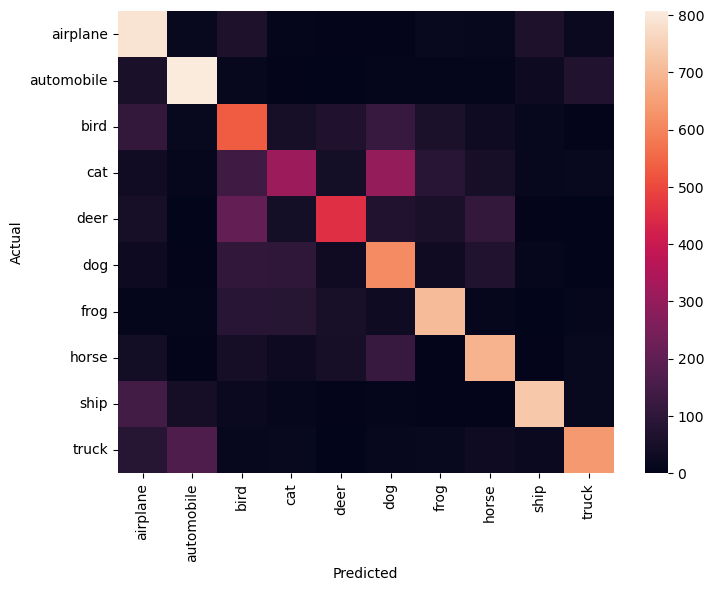

              precision    recall  f1-score   support

    airplane       0.59      0.79      0.68      1000
  automobile       0.75      0.81      0.78      1000
        bird       0.43      0.53      0.48      1000
         cat       0.47      0.31      0.38      1000
        deer       0.64      0.46      0.53      1000
         dog       0.48      0.61      0.54      1000
        frog       0.71      0.71      0.71      1000
       horse       0.68      0.69      0.68      1000
        ship       0.83      0.73      0.78      1000
       truck       0.79      0.64      0.71      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.63     10000
weighted avg       0.64      0.63      0.63     10000



In [11]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test.flatten(), y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test.flatten(), y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted: airplane
Actual: airplane


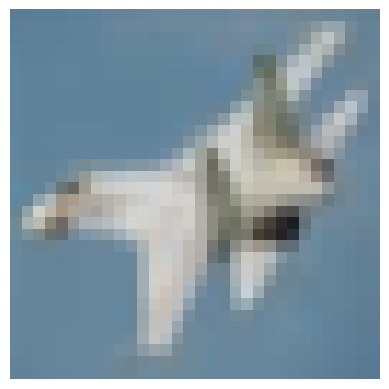

In [9]:
idx = 10

plt.imshow(X_test[idx])
plt.axis("off")

pred = model.predict(X_test[idx:idx+1])
print("Predicted:", class_names[np.argmax(pred)])
print("Actual:", class_names[y_test[idx][0]])